In [1]:
!pip install -q scikit-learn

In [2]:

import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_from_disk, concatenate_datasets, Audio
import glob
from datasets import disable_caching
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_curve,
    auc,
    roc_auc_score,
)

from torchvision.models import resnet18

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/Colab Notebooks/ASP/Project/speaker_chunks/

/content/drive/.shortcut-targets-by-id/1WKvKV35kAMsJDD3_WpAPtPeLQROioHQt/speaker_chunks


In [4]:
import sys
sys.path.append("/content/drive/MyDrive/Colab Notebooks/ASP/Project/speaker_chunks/contrastive/files/utils")

## Load Data and DataLoader (dev and test set)

In [5]:
disable_caching()

# loading data

chunk_paths = sorted(glob.glob("/content/drive/MyDrive/Colab Notebooks/ASP/Project/speaker_chunks/chunk_*"))

chunks = []
for path in chunk_paths:
    ds = load_from_disk(path)
    ds = ds.cast_column("audio_path", Audio(sampling_rate=16000))
    chunks.append(ds)

full_dataset = concatenate_datasets(chunks)

In [6]:
split = full_dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = split["train"]

temp = split["test"].train_test_split(test_size=0.5, seed=42)
dev_dataset = temp["train"]
test_dataset = temp["test"]

In [7]:
from dataset_builder import Dataset_Builder

config = {"shortest_duration": 4.0}
dev_builder = Dataset_Builder(dev_dataset, **config)
dev_builder.filter()
dev_builder.preprocess()

Duration of cropped log-mel spectograms (input):  4.0  seconds


Filter:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2402 [00:00<?, ? examples/s]

In [8]:
dev_dataset = dev_builder.get_dataset()

In [9]:
def collate_fn(batch):
    log_mels = torch.stack([b["log_mel"] for b in batch])
    labels = torch.tensor([b["label"] for b in batch])
    return (log_mels, labels)

In [10]:
BS = 32
dev_loader = DataLoader(
    dev_dataset,
    batch_size=BS,
    collate_fn=collate_fn,
    drop_last=True
)

## Build Model and Load checkpoint

In [12]:
centroids_loaded = np.load("./contrastive/checkpoints/6_epoch_1e-4_lr_50_dim/centroids_epoch_6.npz")

centroids = {key: centroids_loaded[key] for key in centroids_loaded.files}

In [13]:
import json
with open("./contrastive/files/utils/speaker2id.json", "r") as f:
    speaker2id = json.load(f)

In [14]:
id2cent = {}
for key, value in speaker2id.items():
    id2cent[value] = centroids[key]

In [20]:
import torch.nn as nn
from torchvision.models import resnet18

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

class ContrastiveModel(nn.Module):
  def __init__(self, base_model, embed_dim):
    super().__init__()
    self.model = base_model
    self.model.fc = nn.Linear(in_features=512, out_features=embed_dim, bias=True)

  def forward(self, x):
    x = self.model(x)
    return nn.functional.normalize(x, dim=-1) # Avoid representation collapse

base_model = resnet18(weights="DEFAULT")
model = ContrastiveModel(base_model, 50)
model.load_state_dict(torch.load("./contrastive/checkpoints/6_epoch_1e-4_lr_50_dim/epoch_6.pth", map_location=DEVICE, weights_only=True))

extractor = torch.nn.Sequential(*list(model.model.children())[:-1])

model.to(DEVICE)
extractor.to(DEVICE)

model.eval()
extractor.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

## Accuracy Evaluation (for dev set)

In [24]:
from torch.nn.functional import cosine_similarity

all_labels = []
all_probs = []
all_preds = []
all_embs = []
all_inter_embs = []

correct  = 0
total = 0

model.to(DEVICE) # Ensure model is on the correct device

centroids_tensor = torch.tensor(list(id2cent.values())).to(DEVICE)
centroids_tensor = torch.tile(centroids_tensor, dims=(BS, 1, 1))

with torch.no_grad():
  for indx, (log_mels, labels) in tqdm(enumerate(dev_loader), total=len(dev_loader)):
      log_mels = log_mels.to(DEVICE)
      labels = labels.to(DEVICE)

      inter_embed = extractor(log_mels)
      inter_embed = torch.nn.functional.normalize(inter_embed, dim=-1)
      embed = model(log_mels) # Already normalized

      sim = cosine_similarity(embed.unsqueeze(1), centroids_tensor, dim=2)
      _, preds = torch.max(sim, dim=1)

      correct += torch.sum(preds == labels).item()
      total += len(labels)

      all_labels.extend(labels.cpu().numpy())
      all_probs.append(sim.cpu().numpy())
      all_preds.extend(preds.cpu().numpy())
      all_inter_embs.append(inter_embed.cpu().numpy())
      all_embs.append(embed.cpu().numpy())

accuracy = correct / total
print(f"Accuracy = {accuracy:4f}")

100%|██████████| 75/75 [04:01<00:00,  3.22s/it]

Accuracy = 0.898750


## Confusion matrix

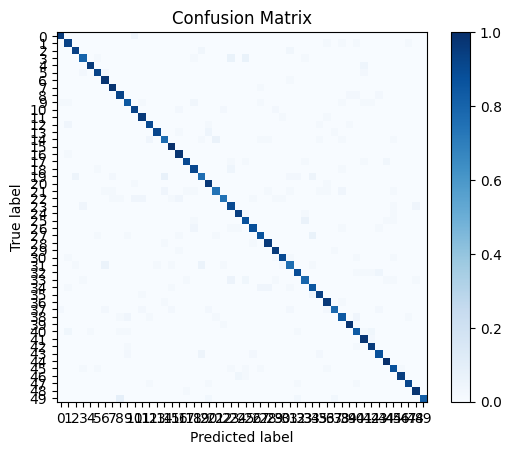

In [25]:
cm = confusion_matrix(all_labels, all_preds, normalize="true")

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", include_values=False, colorbar=True)
plt.title("Confusion Matrix")
plt.show()

In [26]:
import pandas as pd

report = classification_report(
    all_labels,
    all_preds,
    output_dict=True,
    digits=4
)

report_df = pd.DataFrame(report).T

report_df = report_df.iloc[:-3]

report_df

,precision,recall,f1-score,support
0,0.953488,0.953488,0.953488,43.0
1,0.864407,0.927273,0.894737,55.0
2,0.949153,0.933333,0.941176,60.0
3,0.878049,0.800000,0.837209,45.0
4,0.976744,0.954545,0.965517,44.0
5,0.902439,0.925000,0.913580,40.0
6,0.884615,0.978723,0.929293,47.0
7,0.944444,0.980769,0.962264,52.0
8,0.853659,0.921053,0.886076,38.0
9,0.892857,0.847458,0.869565,59.0


In [27]:
from sklearn.metrics import precision_recall_fscore_support

p_micro, r_micro, f_micro, _ = precision_recall_fscore_support(
    all_labels,
    all_preds,
    average="micro"
)

p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
    all_labels,
    all_preds,
    average="macro"
)

print(f"Micro Precision : {p_micro:.4f}")
print(f"Micro Recall    : {r_micro:.4f}")
print(f"Micro F1-score  : {f_micro:.4f}")

print(f"Macro Precision : {p_macro:.4f}")
print(f"Macro Recall    : {r_macro:.4f}")
print(f"Macro F1-score  : {f_macro:.4f}")

Micro Precision : 0.8988
Micro Recall    : 0.8988
Micro F1-score  : 0.8988
Macro Precision : 0.8996
Macro Recall    : 0.8989
Macro F1-score  : 0.8979


## ROC Evaluation

In [28]:
NUM_CLASSES = 50

all_probs = np.concatenate(all_probs, axis=0)
all_labels = np.array(all_labels)

y_true = label_binarize(all_labels, classes=np.arange(NUM_CLASSES))

fpr = {}
tpr = {}
roc_auc = {}

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_true.ravel(), all_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

roc_auc["macro"] = roc_auc_score(y_true, all_probs, average="macro", multi_class="ovr")

print(f"Micro-average ROC AUC: {roc_auc['micro']:.3f}")
print(f"Macro-average ROC AUC: {roc_auc['macro']:.3f}")


Micro-average ROC AUC: 0.995
Macro-average ROC AUC: 0.995


## Plot out ROC Curve

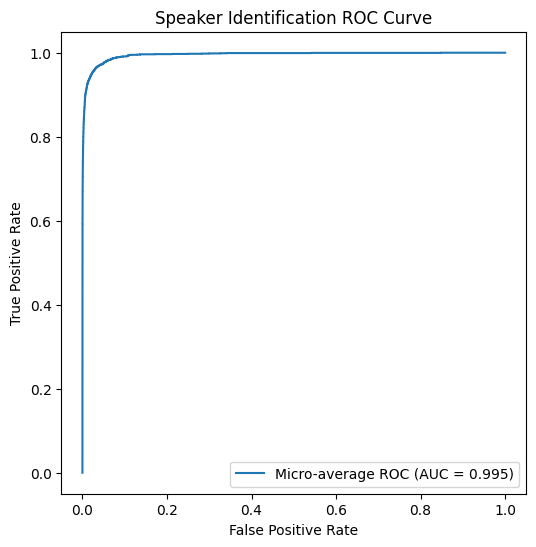

In [29]:
plt.figure(figsize=(6,6))

plt.plot(
    fpr["micro"],
    tpr["micro"],
    label=f"Micro-average ROC (AUC = {roc_auc['micro']:.3f})"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Speaker Identification ROC Curve")
plt.legend()

plt.show()

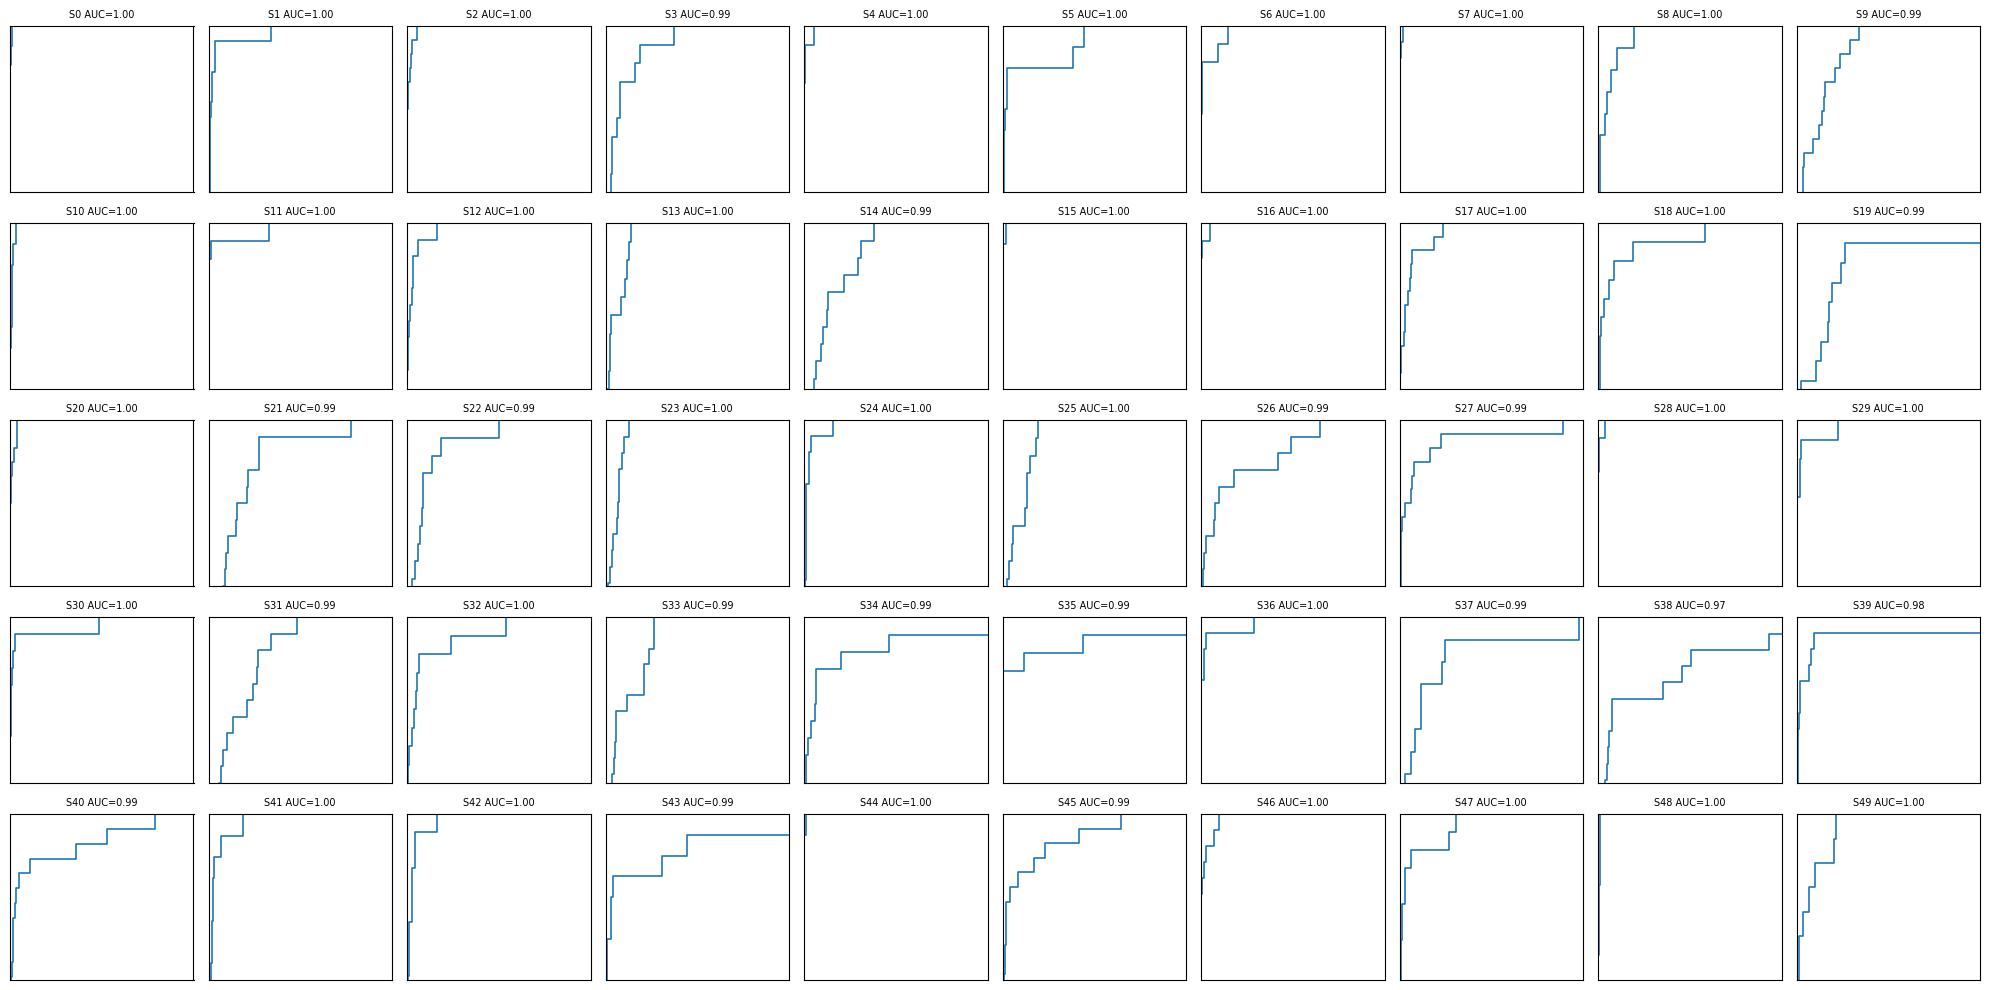

In [30]:
fig, axes = plt.subplots(5, 10, figsize=(20, 10))
axes = axes.ravel()

for i in range(NUM_CLASSES):
    ax = axes[i]

    ax.plot(fpr[i], tpr[i], linewidth=1.2)

    ax.set_title(f"S{i} AUC={roc_auc[i]:.2f}", fontsize=7)

    ax.set_xlim(0, 0.2)
    ax.set_ylim(0.8, 1.0)

    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Extract and visualize speaker embeddings

In [31]:
import umap

In [32]:
def visualize_with_umap(embeddings, labels):
    """Generates a UMAP visualization of the embeddings

    Args:
        embeddings (np.array): an array of all speaker embeddings, shape: (N_files, embedding_size)
        labels (np.array): a 1D list with speaker IDs
    """

    #reduce to 2D using UMAP
    umap_model = umap.UMAP(random_state=42)
    emb_tranform = umap_model.fit_transform(embeddings) #shape: (N_files, 2)

    plt.figure(figsize=(10,8))

    #get unique speakers to assign colors
    unique_speakers = np.unique(labels)

    #plot results
    for speaker in unique_speakers:
        mask = (labels == speaker) # to filter out different speakers from data
        plt.scatter(
            emb_tranform[mask, 0], # type: ignore
            emb_tranform[mask, 1], # type: ignore
            label = speaker,
            s=15
            )

    plt.title("Speaker Embeddings mapped with UMAP", fontsize = 24)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [44]:
"""
all_embs = []
all_ids = []

for elem in dev_dataset:
    #get the log_mel
    log_mel = elem["log_mel"]
    emb = get_speaker_embedding(model, log_mel, DEVICE)
    all_embs.append(emb)

    #extract the corresponding id/label
    id = elem["label"]
    all_ids.append(id)
"""
# 1. Already flat thanks to .extend() inside the loop
all_ids = all_labels
all_flat_preds = all_preds

# 2. These were .append()'ed as batched NumPy arrays, so now flatten
all_embeddings = [sample for batch in all_embs for sample in batch]
all_inter_embeddings = [sample.squeeze() for batch in all_inter_embs for sample in batch]


all_embeddings = np.vstack(all_embeddings)
all_inter_embeddings = np.vstack(all_inter_embeddings)

In [49]:
all_embeddings = np.squeeze(all_embeddings)
print(all_embeddings.shape)
print(all_inter_embeddings.shape)

(2400, 50)
(2400, 512)


### Visualizing all data points with UMAP

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


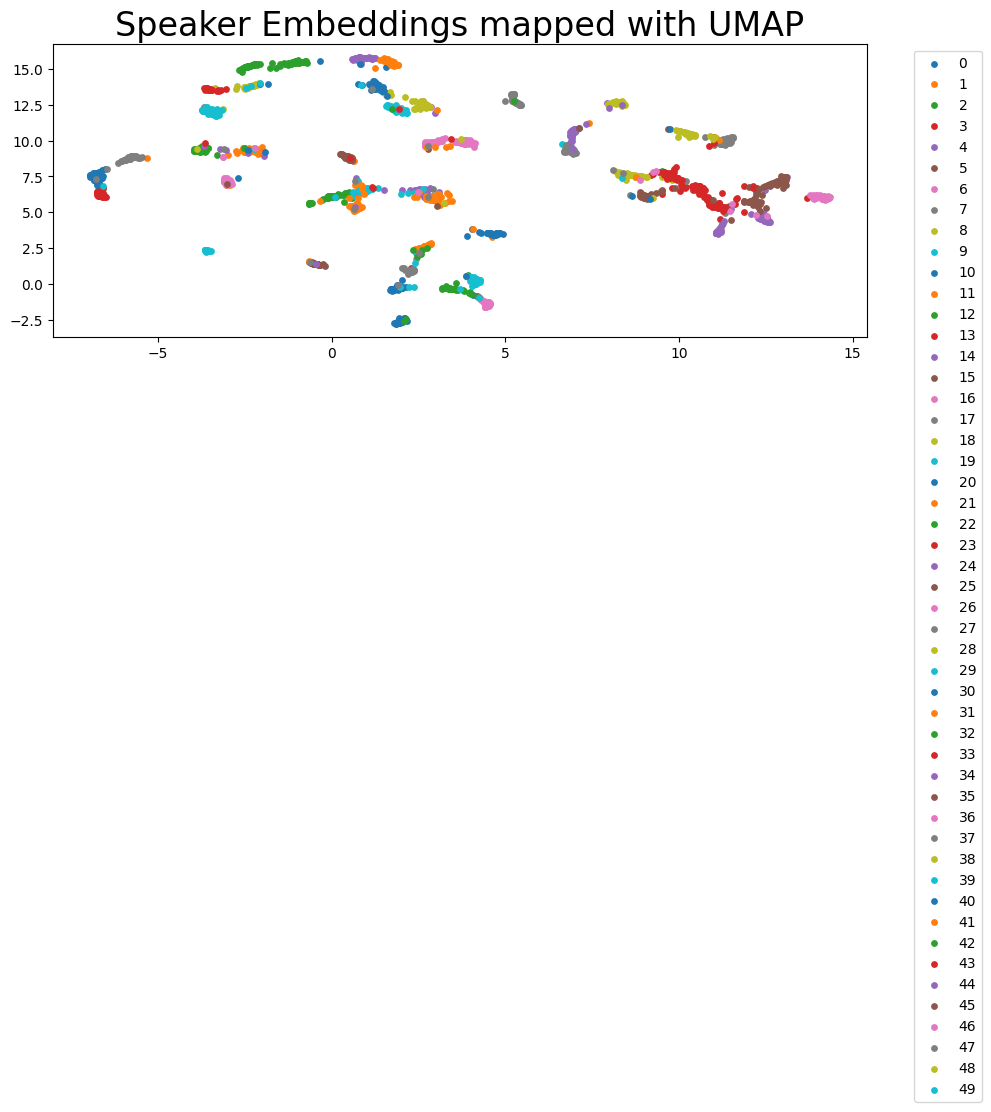

In [50]:
visualize_with_umap(all_embeddings, all_ids)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


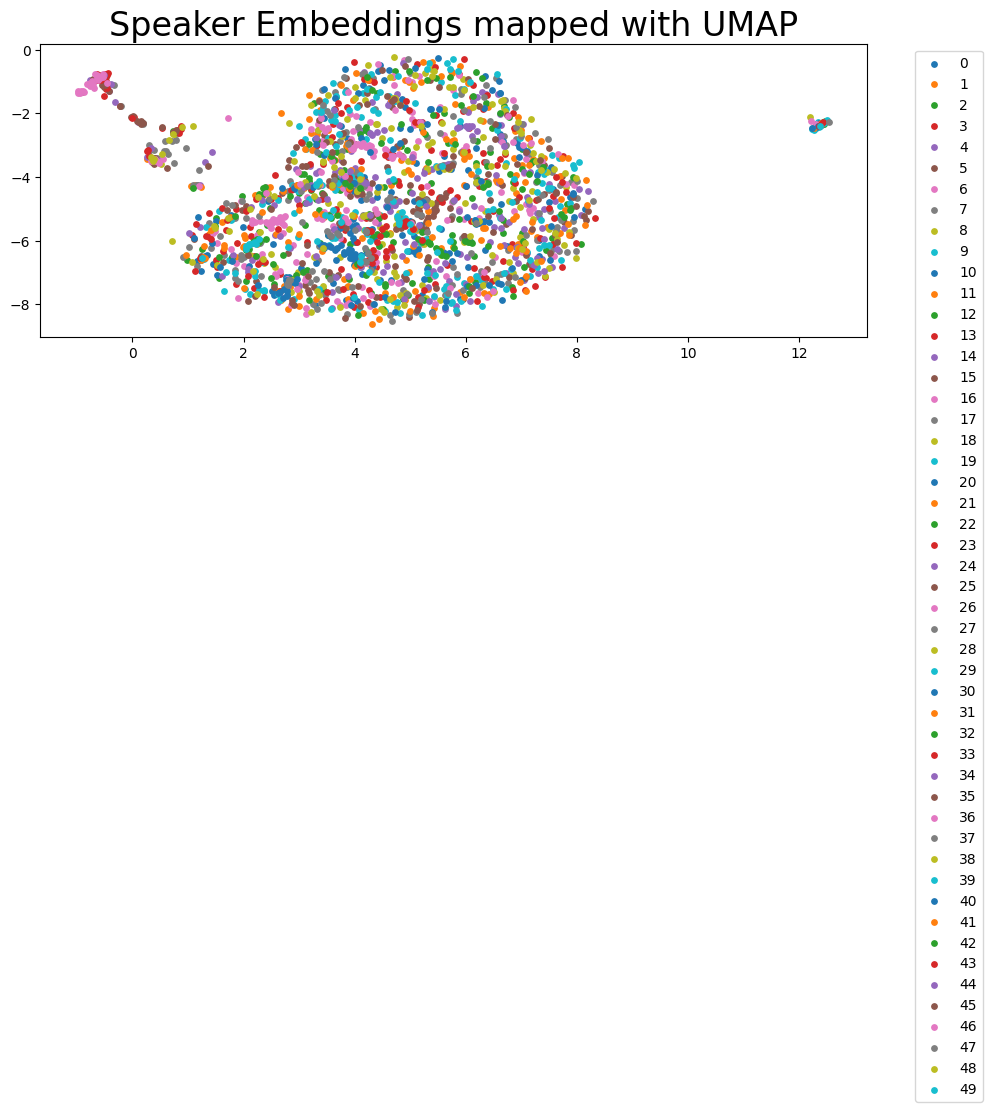

In [51]:
visualize_with_umap(all_inter_embeddings, all_ids)

### Visualizing 10 random speakers' embeddings

In [54]:
all_ids.shape

(2400,)

In [72]:
import random

random.seed(42)
unique_ids = list(set(all_ids))
rand_ids = random.sample(unique_ids, 10)
rand_ids = [int(id) for id in rand_ids]
print(rand_ids)

[40, 7, 1, 17, 15, 14, 8, 6, 34, 5]


In [76]:
rand_embs = []
rand_inter_embs = []
rand_labels = []

for indx, id in enumerate(all_ids):
  if id in rand_ids:
    rand_embs.append(all_embeddings[indx])
    rand_inter_embs.append(all_inter_embeddings[indx])
    rand_labels.append(id)

"""
for elem in test_dataset:
    if elem["label"] in rand_ids:
      log_mel = elem["log_mel"]
      emb = get_speaker_embedding(model, log_mel, DEVICE)
      rand_embs.append(emb)
      # print("Appending successful\n")

      id = elem["label"]
      rand_labels.append(id)
"""

'\nfor elem in test_dataset:\n    if elem["label"] in rand_ids:\n      log_mel = elem["log_mel"]\n      emb = get_speaker_embedding(model, log_mel, DEVICE)\n      rand_embs.append(emb)\n      # print("Appending successful\n")\n\n      id = elem["label"]\n      rand_labels.append(id)\n'

In [77]:
rand_embs = np.vstack(rand_embs)
rand_inter_embs = np.vstack(rand_inter_embs)
rand_embs = np.squeeze(rand_embs)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


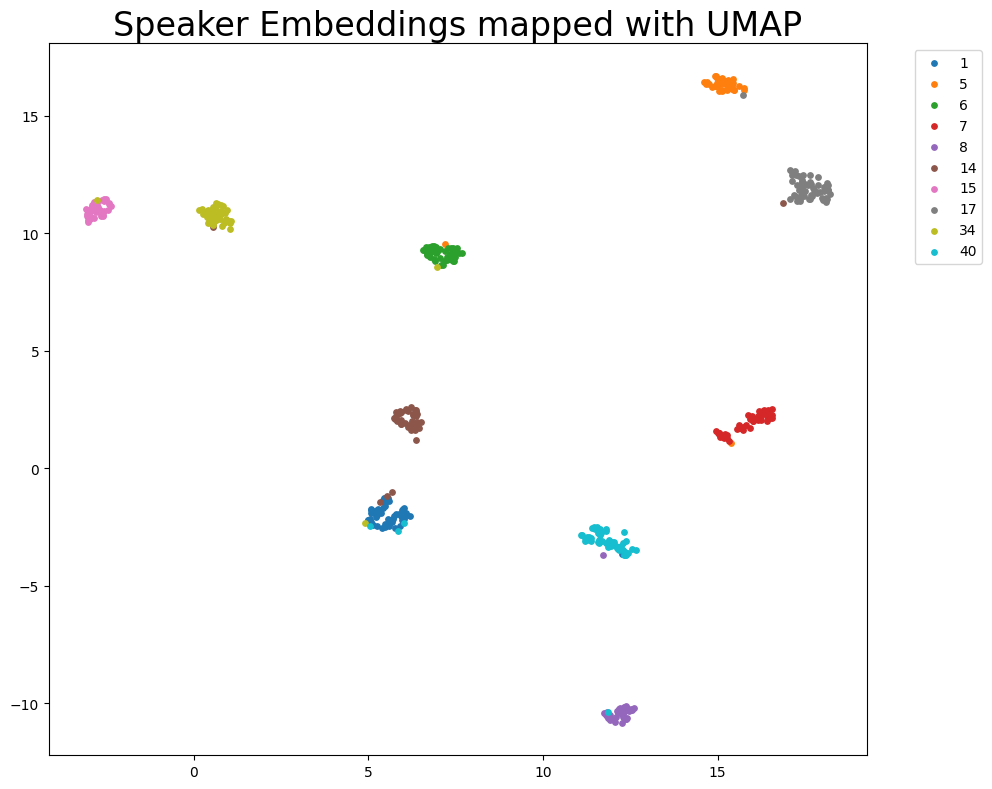

In [75]:
visualize_with_umap(rand_embs, rand_labels)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


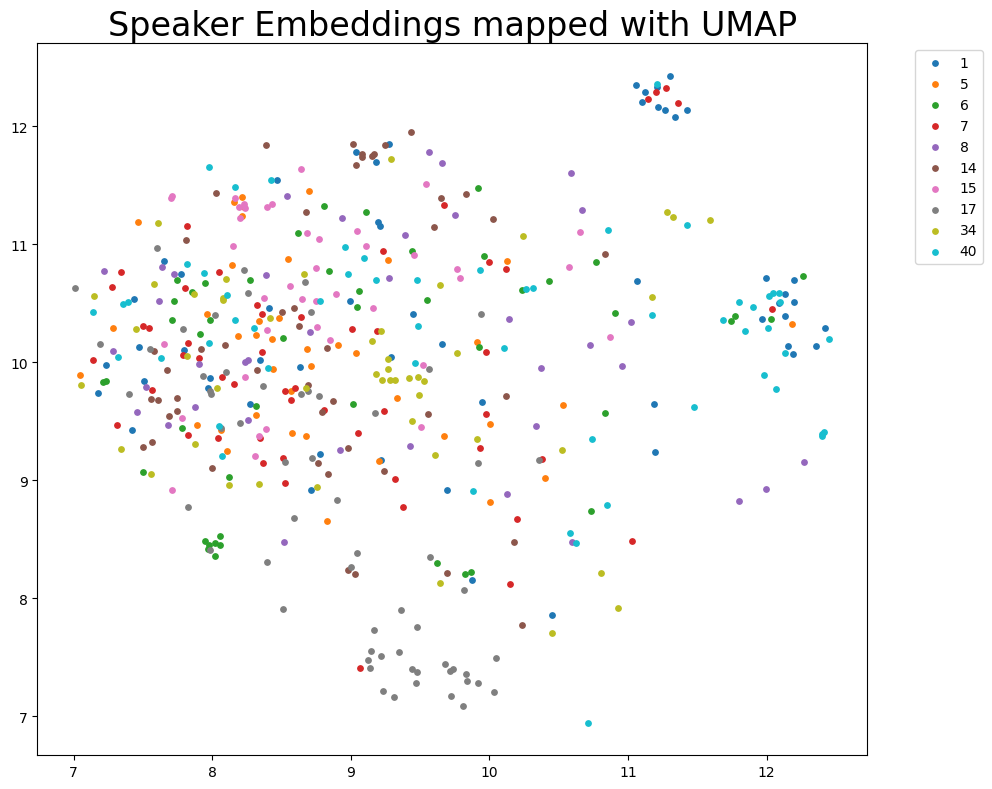

In [78]:
visualize_with_umap(rand_inter_embs, rand_labels)